In [1]:
import pandas as pd
import requests 
import json
import os
#import networkx as nx

import matplotlib.pyplot as plt
#from wordcloud import WordCloud

from collections import defaultdict
import spacy
#import Functions as fn
#import seaborn as sns
import numpy as np  
#from fitter import Fitter
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re

In [2]:
from os import listdir
from os.path import isfile, join

In [3]:
nltk.download("punkt")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /home/jovyan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
nlp = spacy.load("en_core_sci_sm") 

/opt/conda/lib/python3.11/site-packages/spacy/language.py:2195: FutureWarning: Possible set union at position 6328
  deserializers["tokenizer"] = lambda p: self.tokenizer.from_disk(  # type: ignore[union-attr]


In [5]:
pwd

'/home/eidf128/eidf128/shared/export/juliana/export/juliana'

In [6]:
home_dir = '/home/eidf128/eidf128/shared/export/juliana/export/juliana'

### Functions

##### Cleaning

In [7]:
def remove_stop_words(text):
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words("english"))
    filtered = [w for w in tokens if w.lower() not in stop_words and w.isalpha()]

    return filtered

In [8]:
def remove_special_characters(text):
    """
    This function removes special characters from the text.
    :param text: text
    :return: text without special characters
    """
    cleaned_string = re.sub(r'[?|$|.|!|@|#|%|^|&|*|(|)|-|_|+|=|;|:|,|<|>|/|{|}|[|]|~|`|\'|\"|\\]',r'', text)

    return cleaned_string

In [9]:
def clean_text(text):
    if pd.isna(text) or str(text).strip() == "":
        return ""
    text = remove_special_characters(str(text)) or ""
    
    return remove_stop_words(text)

##### Count

In [10]:
# It counts the number of words in a phrase
def count_words(phrase):
    """
    This function counts the number of words in a phrase.
    :param phrase: text

    :return: the number of words in the phrase
    """
    lenght = 0
    if len(phrase) > 1 and phrase.isspace() == True:
        lenght = 1
    
    else:
        words = phrase.split()
        lenght = len(words)
    
    return lenght

In [11]:
# It counts the number of characters in a phrase
def count_characters(phrase):
    """
    This function counts the number of characters in a phrase.
    :param phrase: text

    :return: the number of characters in the phrase
    """
    lenght = 0
    if len(phrase) < 1:
        lenght = 0
    else:
        lenght = len(phrase)
        
    return lenght

##### NLP

In [12]:
# It lemmatizes a text
def lemmatizer(phrase):
    """
    This function lemmatizes a text.
    :param phrase: text

    :return: the lemmatized text
    """
    doc = nlp(phrase)
    lemmatized_tokens = [token.lemma_ for token in doc]
    lemmatized_text = ' '.join(lemmatized_tokens)
    
    return lemmatized_text

In [13]:
# It extracts the entities from a text
def entities_recognition(phrase):
    """
    This function extracts the entities from a text.
    :param phrase: text
    :return: the entities extracted from the text
    """
    entities = []
    doc_phrase = nlp(phrase)
    entities = list(doc_phrase.ents)
    
    return entities

In [14]:
def to_text(x):
    # missing
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return ""
    # already a string
    if isinstance(x, str):
        return x
    # list/tuple/set/np array of tokens
    if isinstance(x, (list, tuple, set, np.ndarray)):
        return " ".join(map(str, x))
    # fallback: convert whatever it is to string
    return str(x)


##### Organization

In [15]:
def first_non_null(s):
    s = s.dropna()
    return s.iloc[0] if len(s) else pd.NA

In [16]:
def join_unique_non_null(s, sep=" | "):
    s = s.dropna().astype(str)
    s = s[s.str.strip().ne("")]           # drop empty strings
    s = pd.unique(s)                      # keep unique (preserve order)
    return sep.join(s) if len(s) else pd.NA

### Reading the data and creating df

In [17]:
data_path = "/home/eidf128/eidf128/shared/export/juliana/export/juliana/idr_metadata"

In [18]:
os.chdir(data_path)

In [19]:
ll

total 0
drwxrwsr-x  4 26161  7 Mar  2 15:58 idr0000-lastname-example/
drwxrwsr-x  5 26161  4 Mar  2 15:58 idr0001-graml-sysgro/
drwxrwsr-x  3 26161  3 Mar  2 15:58 idr0002-heriche-condensation/
drwxrwsr-x  3 26161  2 Mar  2 15:58 idr0003-breker-plasticity/
drwxrwsr-x  6 26161  6 Mar  2 15:58 idr0004-thorpe-rad52/
drwxrwsr-x  4 26161  5 Mar  2 15:58 idr0005-toret-adhesion/
drwxrwsr-x  3 26161  4 Mar  2 15:58 idr0006-fong-nuclearbodies/
drwxrwsr-x  3 26161  4 Mar  2 15:58 idr0007-srikumar-sumo/
drwxrwsr-x  4 26161  7 Mar  2 15:58 idr0008-rohn-actinome/
drwxrwsr-x  4 26161  3 Mar  2 15:58 idr0009-simpson-secretion/
drwxrwsr-x  3 26161  3 Mar  2 15:58 idr0010-doil-dnadamage/
drwxrwsr-x  8 26161  9 Mar  2 15:58 idr0011-ledesmafernandez-dad4/
drwxrwsr-x  7 26161  8 Mar  2 15:59 idr0012-fuchs-cellmorph/
drwxrwsr-x  6 26161  5 Mar  2 15:59 idr0013-neumann-mitocheck/
drwxrwsr-x  4 26161 10 Mar  2 15:59 idr0015-colin-taraoceans/
drwxrwsr-x  4 26161 10 Mar  2 15:59 idr0015-UNKNOWN-taraoceans/
drw

In [20]:
subfolders = [ f.path for f in os.scandir() if f.is_dir() ]
subfolders

['./idr0092-ostrop-organoid',
 './idr0016-wawer-bioactivecompoundprofiling',
 './idr0079-hartmann-lateralline',
 './idr0067-king-yeastmeiosis',
 './idr0134-peters-bryophytes',
 './idr0051-fulton-tailbudlightsheet',
 './idr0020-barr-chtog',
 './idr0150-friedman-cafs',
 './idr0011-ledesmafernandez-dad4',
 './idr0070-kerwin-hdbr',
 './idr0068-shah-zebrafishlightsheet',
 './idr0141-sokol-skinmucosa',
 './idr0025-stadler-proteinatlas',
 './idr0146-dominguez-heartlightsheet',
 './idr0028-pascualvargas-rhogtpases',
 './idr0022-koedoot-cellmigration',
 './idr0012-fuchs-cellmorph',
 './idr0071-feldman-crisprko',
 './idr0021-lawo-pericentriolarmaterial',
 './idr0033-rohban-pathways',
 './idr0040-aymoz-singlecell',
 './idr0065-camsund-crispri',
 './idr0030-sero-yap',
 './idr0116-deboer-npod',
 './idr0099-jain-beetlelightsheet',
 './idr0107-morgan-hei10',
 './idr0036-gustafsdottir-compoundprofiling',
 './idr0032-yang-meristem',
 './idr0148-schumacher-kidneytem',
 './idr0045-reichmann-zygotespindle

In [21]:
new_list_folders = []
for element in subfolders:
    value = str(element)
    value_clean = value.replace('./','')
    new_list_folders.append(value_clean)
    value = []

new_list_folders

['idr0092-ostrop-organoid',
 'idr0016-wawer-bioactivecompoundprofiling',
 'idr0079-hartmann-lateralline',
 'idr0067-king-yeastmeiosis',
 'idr0134-peters-bryophytes',
 'idr0051-fulton-tailbudlightsheet',
 'idr0020-barr-chtog',
 'idr0150-friedman-cafs',
 'idr0011-ledesmafernandez-dad4',
 'idr0070-kerwin-hdbr',
 'idr0068-shah-zebrafishlightsheet',
 'idr0141-sokol-skinmucosa',
 'idr0025-stadler-proteinatlas',
 'idr0146-dominguez-heartlightsheet',
 'idr0028-pascualvargas-rhogtpases',
 'idr0022-koedoot-cellmigration',
 'idr0012-fuchs-cellmorph',
 'idr0071-feldman-crisprko',
 'idr0021-lawo-pericentriolarmaterial',
 'idr0033-rohban-pathways',
 'idr0040-aymoz-singlecell',
 'idr0065-camsund-crispri',
 'idr0030-sero-yap',
 'idr0116-deboer-npod',
 'idr0099-jain-beetlelightsheet',
 'idr0107-morgan-hei10',
 'idr0036-gustafsdottir-compoundprofiling',
 'idr0032-yang-meristem',
 'idr0148-schumacher-kidneytem',
 'idr0045-reichmann-zygotespindle',
 'idr0015-colin-taraoceans',
 'idr0114-lindsay-hdbr',
 'i

In [22]:
pattern = r'^idr.*\-study.txt$'
dfs_IDR = []

for folder in new_list_folders:
    os.chdir(data_path + '/'+ folder)

    onlyfiles = [f for f in listdir(data_path + '/'+ folder) if isfile(join(data_path + '/'+ folder, f))]
    onlytext = [f for f in onlyfiles if re.search(pattern, f)]

    if len(onlytext) > 1:
        print('More than one text file in ' + folder)
    #print(onlytext)

    file_name = str(onlytext)
    file_name_clean = file_name.replace('[','').replace(']','').replace('\'','')

    if len(onlytext) == 0:
        print('No text file in ' + folder)
        continue

    if file_name_clean == '[]':
        print('No text file in ' + folder)
        continue

    else:

        with open(file_name_clean, encoding='latin1') as f:
            lines = f.readlines()

            dataFrame = pd.DataFrame(lines)

            for line in lines:
                if re.findall(r'^[A-Za-z]+', line):
                    test = line.split('\t')

                    if len(test) <= 1:
                        #print(test[0] + folder)
                        header = test[0]
                        header = header.replace(' ', '_')
                        content = 'None'
                        continue

                    else:                    
                    
                        header = test[0]
                        header = header.replace(' ', '_')
                        content = test[1]

                        if content == '':
                            dataFrame[header] = 'None'

                        else:
                            dataFrame[header] = content

            dataFrame.drop(0, axis=1, inplace=True)
            dataFrame.drop_duplicates(inplace=True)

            dfs_IDR.append(dataFrame)

    os.chdir('/home/eidf128/eidf128/shared/export/juliana/export/juliana')

No text file in idr0000-lastname-example


In [25]:
type(dfs_IDR)

list

In [26]:
df_IDR = pd.concat(dfs_IDR)
df_IDR

,Comment[IDR_Study_Accession],Study_Title,Study_Type,Study_Type_Term_Source_REF,Study_Type_Term_Accession,Study_Description,Study_Key_Words,Study_Organism,Study_Organism_Term_Source_REF,Study_Organism_Term_Accession,...,CK5,Fibronectin,Location_Center_X,Location_Center_Y,SOM_nodes,pg_cluster,description,firstobjectnumber,secondobjectnumber,Phenotype_Annotation_Level
0,idr0092,A semi-automated organoid screening method dem...,compound library screen,EFO,EFO_0007553,Intestinal organoids are an excellent model to...,Organoids,Mus musculus,NCBITaxon,10090,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,idr0016,Human U2OS cells - compound cell-painting expe...,high content screen,EFO,EFO_0007550,Phenotypic profiling attempts to summarize mul...,NaN,Homo sapiens,NCBITaxon,NCBITaxon_9606,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,idr0079,An Image-Based Data-Driven Analysis of Cellula...,microscopy assay,EFO,EFO_0002909,A data-driven analysis of cell morphology and ...,image analysis,Danio rerio,NCBITaxon,7955,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,idr0067,Meiotic cellular rejuvenation is coupled to nu...,time-lapse imaging,OMIT,OMIT_0027490,Production of healthy gametes in meiosis relie...,meiosis,Saccharomyces cerevisiae\n,NCBITaxon,4932,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,idr0134,Reference BioImaging dataset to assess the phe...,histology,None,None,"Here, we present a high-quality reference data...",phenotypes,Diplophyllum albicans,NCBITaxon,264775,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,idr0023,Nuclear pore scaffold structure analyzed by su...,protein localization,EFO,GO:0008104,Much of life's essential molecular machinery c...,NaN,Homo sapiens,NCBITaxon,NCBITaxon_9606,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,idr0038,Ex vivo live cell tracking in kidney organoids...,time-lapse imaging,OMIT,OMIT_0027490,We have adapted the mouse kidney rudiment assa...,NaN,Mus musculus,NCBITaxon,NCBITaxon_10090,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,idr0138,Integration of spatial and single-cell transcr...,seqFISH,EFO,EFO_0008991,Molecular profiling of single cells has advanc...,seqFISH,Mus musculus,NCBITaxon,10090,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,idr0128,Parallel compound screen for infection modulat...,high content screen,EFO,EFO_0007550,Viral infectious diseases span a myriad of mal...,Influenza A virus,Homo sapiens,NCBITaxon,9606,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Cleaning

In [27]:
# Replace None with nothing
df_IDR.replace(to_replace = [None], value="", inplace = True)

,Comment[IDR_Study_Accession],Study_Title,Study_Type,Study_Type_Term_Source_REF,Study_Type_Term_Accession,Study_Description,Study_Key_Words,Study_Organism,Study_Organism_Term_Source_REF,Study_Organism_Term_Accession,...,CK5,Fibronectin,Location_Center_X,Location_Center_Y,SOM_nodes,pg_cluster,description,firstobjectnumber,secondobjectnumber,Phenotype_Annotation_Level
0,idr0092,A semi-automated organoid screening method dem...,compound library screen,EFO,EFO_0007553,Intestinal organoids are an excellent model to...,Organoids,Mus musculus,NCBITaxon,10090,...,,,,,,,,,,
0,idr0016,Human U2OS cells - compound cell-painting expe...,high content screen,EFO,EFO_0007550,Phenotypic profiling attempts to summarize mul...,,Homo sapiens,NCBITaxon,NCBITaxon_9606,...,,,,,,,,,,
0,idr0079,An Image-Based Data-Driven Analysis of Cellula...,microscopy assay,EFO,EFO_0002909,A data-driven analysis of cell morphology and ...,image analysis,Danio rerio,NCBITaxon,7955,...,,,,,,,,,,
0,idr0067,Meiotic cellular rejuvenation is coupled to nu...,time-lapse imaging,OMIT,OMIT_0027490,Production of healthy gametes in meiosis relie...,meiosis,Saccharomyces cerevisiae\n,NCBITaxon,4932,...,,,,,,,,,,
0,idr0134,Reference BioImaging dataset to assess the phe...,histology,None,None,"Here, we present a high-quality reference data...",phenotypes,Diplophyllum albicans,NCBITaxon,264775,...,,,,,,,,,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,idr0023,Nuclear pore scaffold structure analyzed by su...,protein localization,EFO,GO:0008104,Much of life's essential molecular machinery c...,,Homo sapiens,NCBITaxon,NCBITaxon_9606,...,,,,,,,,,,
0,idr0038,Ex vivo live cell tracking in kidney organoids...,time-lapse imaging,OMIT,OMIT_0027490,We have adapted the mouse kidney rudiment assa...,,Mus musculus,NCBITaxon,NCBITaxon_10090,...,,,,,,,,,,
0,idr0138,Integration of spatial and single-cell transcr...,seqFISH,EFO,EFO_0008991,Molecular profiling of single cells has advanc...,seqFISH,Mus musculus,NCBITaxon,10090,...,,,,,,,,,,
0,idr0128,Parallel compound screen for infection modulat...,high content screen,EFO,EFO_0007550,Viral infectious diseases span a myriad of mal...,Influenza A virus,Homo sapiens,NCBITaxon,9606,...,,,,,,,,,,


In [28]:
# Everything to lowercase
obj_cols = df_IDR.select_dtypes(include = ["object", "string"]).columns #Select columns that have strings on it
df_IDR[obj_cols] = df_IDR[obj_cols].astype("string").apply(lambda s: s.str.lower())

In [29]:
df_IDR = df_IDR.reset_index(drop=True)

In [30]:
df_IDR["Study_Description_clean"] = pd.Series(index = df_IDR.index, dtype="object")

In [31]:
df_IDR["Experiment_Description_clean"] = pd.Series(index = df_IDR.index, dtype="object")

In [32]:
df2 = df_IDR.reset_index(drop=True)
col = "Study_Description"

for i, row in df2.iterrows():
    print(f"Processing row {i+1}/{len(df2)}")

    value_to_clean = row[col]
    if pd.notna(value_to_clean) and value_to_clean != "":
        df2.at[i, f"{col}_clean"] = clean_text(value_to_clean)

df_IDR = df2

Processing row 1/132
Processing row 2/132
Processing row 3/132
Processing row 4/132
Processing row 5/132
Processing row 6/132
Processing row 7/132
Processing row 8/132
Processing row 9/132
Processing row 10/132
Processing row 11/132
Processing row 12/132
Processing row 13/132
Processing row 14/132
Processing row 15/132
Processing row 16/132
Processing row 17/132
Processing row 18/132
Processing row 19/132
Processing row 20/132
Processing row 21/132
Processing row 22/132
Processing row 23/132
Processing row 24/132
Processing row 25/132
Processing row 26/132
Processing row 27/132
Processing row 28/132
Processing row 29/132
Processing row 30/132
Processing row 31/132
Processing row 32/132
Processing row 33/132
Processing row 34/132
Processing row 35/132
Processing row 36/132
Processing row 37/132
Processing row 38/132
Processing row 39/132
Processing row 40/132
Processing row 41/132
Processing row 42/132
Processing row 43/132
Processing row 44/132
Processing row 45/132
Processing row 46/1

In [35]:
df3 = df_IDR.reset_index(drop=True)
col = "Experiment_Description"

for i, row in df2.iterrows():
    print(f"Processing row {i+1}/{len(df3)}")

    value_to_clean = row[col]
    if pd.notna(value_to_clean) and value_to_clean != "":
        df3.at[i, f"{col}_clean"] = clean_text(value_to_clean)

df_IDR = df3

Processing row 1/132
Processing row 2/132
Processing row 3/132
Processing row 4/132
Processing row 5/132
Processing row 6/132
Processing row 7/132
Processing row 8/132
Processing row 9/132
Processing row 10/132
Processing row 11/132
Processing row 12/132
Processing row 13/132
Processing row 14/132
Processing row 15/132
Processing row 16/132
Processing row 17/132
Processing row 18/132
Processing row 19/132
Processing row 20/132
Processing row 21/132
Processing row 22/132
Processing row 23/132
Processing row 24/132
Processing row 25/132
Processing row 26/132
Processing row 27/132
Processing row 28/132
Processing row 29/132
Processing row 30/132
Processing row 31/132
Processing row 32/132
Processing row 33/132
Processing row 34/132
Processing row 35/132
Processing row 36/132
Processing row 37/132
Processing row 38/132
Processing row 39/132
Processing row 40/132
Processing row 41/132
Processing row 42/132
Processing row 43/132
Processing row 44/132
Processing row 45/132
Processing row 46/1

### Stats

In [36]:
df_IDR

,Comment[IDR_Study_Accession],Study_Title,Study_Type,Study_Type_Term_Source_REF,Study_Type_Term_Accession,Study_Description,Study_Key_Words,Study_Organism,Study_Organism_Term_Source_REF,Study_Organism_Term_Accession,...,Location_Center_X,Location_Center_Y,SOM_nodes,pg_cluster,description,firstobjectnumber,secondobjectnumber,Phenotype_Annotation_Level,Study_Description_clean,Experiment_Description_clean
0,idr0092,a semi-automated organoid screening method dem...,compound library screen,efo,efo_0007553,intestinal organoids are an excellent model to...,organoids,mus musculus,ncbitaxon,10090,...,,,,,,,,,"[intestinal, organoids, excellent, model, stud...",NaN
1,idr0016,human u2os cells - compound cell-painting expe...,high content screen,efo,efo_0007550,phenotypic profiling attempts to summarize mul...,,homo sapiens,ncbitaxon,ncbitaxon_9606,...,,,,,,,,,"[phenotypic, profiling, attempts, summarize, m...",NaN
2,idr0079,an image-based data-driven analysis of cellula...,microscopy assay,efo,efo_0002909,a data-driven analysis of cell morphology and ...,image analysis,danio rerio,ncbitaxon,7955,...,,,,,,,,,"[analysis, cell, morphology, intracellular, or...","[confocal, imaging, fixed, samples, zebrafish,..."
3,idr0067,meiotic cellular rejuvenation is coupled to nu...,time-lapse imaging,omit,omit_0027490,production of healthy gametes in meiosis relie...,meiosis,saccharomyces cerevisiae\n,ncbitaxon,4932,...,,,,,,,,,"[production, healthy, gametes, meiosis, relies...","[fixed, cell, fluorescence, microscopy, transm..."
4,idr0134,reference bioimaging dataset to assess the phe...,histology,none,none,"here, we present a high-quality reference data...",phenotypes,diplophyllum albicans,ncbitaxon,264775,...,,,,,,,,,"[present, reference, dataset, containing, macr...","[representative, voucher, specimens, received,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,idr0023,nuclear pore scaffold structure analyzed by su...,protein localization,efo,go:0008104,much of life's essential molecular machinery c...,,homo sapiens,ncbitaxon,ncbitaxon_9606,...,,,,,,,,,"[much, lifes, essential, molecular, machinery,...","[systematic, immunolabelling, complex, monomer..."
128,idr0038,ex vivo live cell tracking in kidney organoids...,time-lapse imaging,omit,omit_0027490,we have adapted the mouse kidney rudiment assa...,,mus musculus,ncbitaxon,ncbitaxon_10090,...,,,,,,,,,"[adapted, mouse, kidney, rudiment, assay, gene...","[adapted, mouse, kidney, rudiment, assay, gene..."
129,idr0138,integration of spatial and single-cell transcr...,seqfish,efo,efo_0008991,molecular profiling of single cells has advanc...,seqfish,mus musculus,ncbitaxon,10090,...,,,,,,,,,"[molecular, profiling, single, cells, advanced...","[seqfish, study, sagittal, sections, mouse, em..."
130,idr0128,parallel compound screen for infection modulat...,high content screen,efo,efo_0007550,viral infectious diseases span a myriad of mal...,influenza a virus,homo sapiens,ncbitaxon,9606,...,,,,,,,,,"[viral, infectious, diseases, span, myriad, ma...",NaN


In [37]:
df_IDR["Study_Description_word_count_clean"] = pd.Series(index=df_IDR.index, dtype="object")

In [38]:
df_IDR["Experiment_Description_word_count_clean"] = pd.Series(index=df_IDR.index, dtype="object")

In [39]:
df_IDR["Study_Description_word_count_clean"] = (
    df_IDR["Study_Description_clean"].apply(lambda x: len(x) if isinstance(x, list) else 0)
)

In [40]:
df_IDR["Experiment_Description_word_count_clean"] = (
    df_IDR["Experiment_Description_clean"].apply(lambda x: len(x) if isinstance(x, list) else 0)
)

In [41]:
df_IDR

,Comment[IDR_Study_Accession],Study_Title,Study_Type,Study_Type_Term_Source_REF,Study_Type_Term_Accession,Study_Description,Study_Key_Words,Study_Organism,Study_Organism_Term_Source_REF,Study_Organism_Term_Accession,...,SOM_nodes,pg_cluster,description,firstobjectnumber,secondobjectnumber,Phenotype_Annotation_Level,Study_Description_clean,Experiment_Description_clean,Study_Description_word_count_clean,Experiment_Description_word_count_clean
0,idr0092,a semi-automated organoid screening method dem...,compound library screen,efo,efo_0007553,intestinal organoids are an excellent model to...,organoids,mus musculus,ncbitaxon,10090,...,,,,,,,"[intestinal, organoids, excellent, model, stud...",NaN,89,0
1,idr0016,human u2os cells - compound cell-painting expe...,high content screen,efo,efo_0007550,phenotypic profiling attempts to summarize mul...,,homo sapiens,ncbitaxon,ncbitaxon_9606,...,,,,,,,"[phenotypic, profiling, attempts, summarize, m...",NaN,182,0
2,idr0079,an image-based data-driven analysis of cellula...,microscopy assay,efo,efo_0002909,a data-driven analysis of cell morphology and ...,image analysis,danio rerio,ncbitaxon,7955,...,,,,,,,"[analysis, cell, morphology, intracellular, or...","[confocal, imaging, fixed, samples, zebrafish,...",60,20
3,idr0067,meiotic cellular rejuvenation is coupled to nu...,time-lapse imaging,omit,omit_0027490,production of healthy gametes in meiosis relie...,meiosis,saccharomyces cerevisiae\n,ncbitaxon,4932,...,,,,,,,"[production, healthy, gametes, meiosis, relies...","[fixed, cell, fluorescence, microscopy, transm...",99,29
4,idr0134,reference bioimaging dataset to assess the phe...,histology,none,none,"here, we present a high-quality reference data...",phenotypes,diplophyllum albicans,ncbitaxon,264775,...,,,,,,,"[present, reference, dataset, containing, macr...","[representative, voucher, specimens, received,...",32,508
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,idr0023,nuclear pore scaffold structure analyzed by su...,protein localization,efo,go:0008104,much of life's essential molecular machinery c...,,homo sapiens,ncbitaxon,ncbitaxon_9606,...,,,,,,,"[much, lifes, essential, molecular, machinery,...","[systematic, immunolabelling, complex, monomer...",75,11
128,idr0038,ex vivo live cell tracking in kidney organoids...,time-lapse imaging,omit,omit_0027490,we have adapted the mouse kidney rudiment assa...,,mus musculus,ncbitaxon,ncbitaxon_10090,...,,,,,,,"[adapted, mouse, kidney, rudiment, assay, gene...","[adapted, mouse, kidney, rudiment, assay, gene...",79,161
129,idr0138,integration of spatial and single-cell transcr...,seqfish,efo,efo_0008991,molecular profiling of single cells has advanc...,seqfish,mus musculus,ncbitaxon,10090,...,,,,,,,"[molecular, profiling, single, cells, advanced...","[seqfish, study, sagittal, sections, mouse, em...",100,19
130,idr0128,parallel compound screen for infection modulat...,high content screen,efo,efo_0007550,viral infectious diseases span a myriad of mal...,influenza a virus,homo sapiens,ncbitaxon,9606,...,,,,,,,"[viral, infectious, diseases, span, myriad, ma...",NaN,99,0


In [42]:
list_headers_stats_clean = ["Study_Description_clean", "Experiment_Description_clean"]

In [43]:
# Creating the empty columns for lemma text and entities 
for header in list_headers_stats_clean:
    df_IDR[f"{header}_lemmatize"] = pd.Series(index = df_IDR.index, dtype="object")
    df_IDR[f"{header}_entities"]  = pd.Series(index = df_IDR.index, dtype="object")

In [44]:
# Lemmatisation and entity recognition
for idx, row in df_IDR.iterrows():
    for header in list_headers_stats_clean: 
        
        text = df_IDR.at[idx, header]
        join_text = to_text(text)
        
        lemma_str = lemmatizer("" if pd.isna(join_text) else str(join_text))
        title_lemma = f"{header}_lemmatize"
        df_IDR.at[idx, title_lemma] = lemma_str

        entities = entities_recognition(lemma_str)
        title_entities = f"{header}_entities"
        df_IDR.at[idx, title_entities] = list(entities)

In [45]:
df_IDR

,Comment[IDR_Study_Accession],Study_Title,Study_Type,Study_Type_Term_Source_REF,Study_Type_Term_Accession,Study_Description,Study_Key_Words,Study_Organism,Study_Organism_Term_Source_REF,Study_Organism_Term_Accession,...,secondobjectnumber,Phenotype_Annotation_Level,Study_Description_clean,Experiment_Description_clean,Study_Description_word_count_clean,Experiment_Description_word_count_clean,Study_Description_clean_lemmatize,Study_Description_clean_entities,Experiment_Description_clean_lemmatize,Experiment_Description_clean_entities
0,idr0092,a semi-automated organoid screening method dem...,compound library screen,efo,efo_0007553,intestinal organoids are an excellent model to...,organoids,mus musculus,ncbitaxon,10090,...,,,"[intestinal, organoids, excellent, model, stud...",NaN,89,0,intestinal organoid excellent model study epit...,"[(intestinal), (model, study), (epithelial, bi...",,[]
1,idr0016,human u2os cells - compound cell-painting expe...,high content screen,efo,efo_0007550,phenotypic profiling attempts to summarize mul...,,homo sapiens,ncbitaxon,ncbitaxon_9606,...,,,"[phenotypic, profiling, attempts, summarize, m...",NaN,182,0,phenotypic profiling attempt summarize multipa...,"[(phenotypic, profiling), (multiparametric, an...",,[]
2,idr0079,an image-based data-driven analysis of cellula...,microscopy assay,efo,efo_0002909,a data-driven analysis of cell morphology and ...,image analysis,danio rerio,ncbitaxon,7955,...,,,"[analysis, cell, morphology, intracellular, or...","[confocal, imaging, fixed, samples, zebrafish,...",60,20,analysis cell morphology intracellular organiz...,"[(morphology), (intracellular), (organization)...",confocal imaging fixed sample zebrafish poster...,"[(confocal, imaging), (posterior, lateral, lin..."
3,idr0067,meiotic cellular rejuvenation is coupled to nu...,time-lapse imaging,omit,omit_0027490,production of healthy gametes in meiosis relie...,meiosis,saccharomyces cerevisiae\n,ncbitaxon,4932,...,,,"[production, healthy, gametes, meiosis, relies...","[fixed, cell, fluorescence, microscopy, transm...",99,29,production healthy gamete meiosis rely quality...,"[(production), (healthy), (meiosis), (quality)...",fix cell fluorescence microscopy transmission ...,"[(cell, fluorescence, microscopy), (image), (y..."
4,idr0134,reference bioimaging dataset to assess the phe...,histology,none,none,"here, we present a high-quality reference data...",phenotypes,diplophyllum albicans,ncbitaxon,264775,...,,,"[present, reference, dataset, containing, macr...","[representative, voucher, specimens, received,...",32,508,present reference dataset contain macroscopic ...,"[(dataset), (macroscopic), (phenotypic, proper...",representative voucher specimen receive herbar...,"[(specimen), (herbaria), (sample, diplophyllum..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,idr0023,nuclear pore scaffold structure analyzed by su...,protein localization,efo,go:0008104,much of life's essential molecular machinery c...,,homo sapiens,ncbitaxon,ncbitaxon_9606,...,,,"[much, lifes, essential, molecular, machinery,...","[systematic, immunolabelling, complex, monomer...",75,11,much lifes essential molecular machinery consi...,"[(lifes), (molecular, machinery), (protein, as...",systematic immunolabelling complex monomeric e...,"[(systematic, immunolabelling), (complex), (mo..."
128,idr0038,ex vivo live cell tracking in kidney organoids...,time-lapse imaging,omit,omit_0027490,we have adapted the mouse kidney rudiment assa...,,mus musculus,ncbitaxon,ncbitaxon_10090,...,,,"[adapted, mouse, kidney, rudiment, assay, gene...","[adapted, mouse, kidney, rudiment, assay, gene...",79,161,adapt mouse kidney rudiment assay generate ren...,"[(adapt), (mouse, kidney, rudiment, assay), (r...",adapt mouse kidney rudiment assay generate ren...,"[(adapt), (mouse, kidney, rudiment, assay), (r..."
129,idr0138,integration of spatial and single-cell transcr...,seqfish,efo,efo_0008991,molecular profiling of si

### Saving the dataset for future work 

In [46]:
os.getcwd()

'/home/eidf128/eidf128/shared/export/juliana/export/juliana'

In [47]:
df_IDR.to_csv("df_IDR_collapse_20260406.csv")

### Statistical analysis

In [7]:
from collections import Counter

In [8]:
df_IDR = pd.read_csv("df_IDR_collapse_20260406.csv")

In [96]:
df_IDR

,Unnamed: 0,Comment[IDR_Study_Accession],Study_Title,Study_Type,Study_Type_Term_Source_REF,Study_Type_Term_Accession,Study_Description,Study_Key_Words,Study_Organism,Study_Organism_Term_Source_REF,...,entities,entities_counter,entities_count,unique_entities_count,Study_Description_clean_entities_white_spaces,all_entities,global_counts,ratio_entities_per_word,ratio_bin,all_entities_clean_entities_white_spaces
0,0,idr0092,a semi-automated organoid screening method dem...,compound library screen,efo,efo_0007553,intestinal organoids are an excellent model to...,organoids,mus musculus,ncbitaxon,...,"[['[intestinal, model study, epithelial biol...","{'['[intestinal': 1, ' model study': 1, ' epit...",35,30,"[[intestinal,, model, study,, epithelial, biol...","[[intestinal, model study, epithelial biology,...",89,0.651685,"(0.6, 0.7]","[[, [intestinal,, model, study,, epithelial, b..."
1,1,idr0016,human u2os cells - compound cell-painting expe...,high content screen,efo,efo_0007550,phenotypic profiling attempts to summarize mul...,NaN,homo sapiens,ncbitaxon,...,"[['[phenotypic profiling, multiparametric ana...","{'['[phenotypic profiling': 1, ' multiparametr...",58,49,"[[phenotypic, profiling,, multiparametric, ana...","[[phenotypic profiling, multiparametric analys...",182,0.494505,"(0.4, 0.5]","[[, [phenotypic, profiling,, multiparametric, ..."
2,2,idr0079,an image-based data-driven analysis of cellula...,microscopy assay,efo,efo_0002909,a data-driven analysis of cell morphology and ...,image analysis,danio rerio,ncbitaxon,...,"[['[morphology, intracellular, organization,...","{'['[morphology': 1, ' intracellular': 2, ' or...",30,27,"[[morphology,, intracellular,, organization,, ...","[[morphology, intracellular, organization, zeb...",80,0.687500,"(0.6, 0.7]","[[, [morphology,, intracellular,, organization..."
3,3,idr0067,meiotic cellular rejuvenation is coupled to nu...,time-lapse imaging,omit,omit_0027490,production of healthy gametes in meiosis relie...,meiosis,saccharomyces cerevisiae\n,ncbitaxon,...,"[['[production, healthy, meiosis, quality, ...","{'['[production': 1, ' healthy': 1, ' meiosis'...",40,35,"[[production,, healthy,, meiosis,, quality,, d...","[[production, healthy, meiosis, quality, distr...",128,0.570312,"(0.5, 0.6]","[[, [production,, healthy,, meiosis,, quality,..."
4,4,idr0134,reference bioimaging dataset to assess the phe...,histology,none,none,"here, we present a high-quality reference data...",phenotypes,diplophyllum albicans,ncbitaxon,...,"[['[dataset, macroscopic, phenotypic propert...","{'['[dataset': 1, ' macroscopic': 2, ' phenoty...",148,109,"[[dataset,, macroscopic,, phenotypic, property...","[[dataset, macroscopic, phenotypic property sp...",540,0.431481,"(0.4, 0.5]","[[, [dataset,, macroscopic,, phenotypic, prope..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,127,idr0023,nuclear pore scaffold structure analyzed by su...,protein localization,efo,go:0008104,much of life's essential molecular machinery c...,NaN,homo sapiens,ncbitaxon,...,"[['[lifes, molecular machinery, protein asse...","{'['[lifes': 1, ' molecular machinery': 1, ' p...",27,27,"[[lifes,, molecular, machinery,, protein, asse...","[[lifes, molecular machinery, protein assembly...",86,0.523256,"(0.5, 0.6]","[[, [lifes,, molecular, machinery,, protein, a..."
128,128,idr0038,ex vivo live cell tracking in kidney organoids...,time-lapse imaging,omit,omit_0027490,we have adapted the mouse kidney rudiment assa...,NaN,mus musculus,ncbitaxon,...,"[['[adapt, mouse kidney rudiment assay, rena...","{'['[adapt': 1, ' mouse kidney rudiment assay'...",60,52,"[[adapt,, mouse, kidney, rudiment, assay,, ren...","[[adapt, mouse kidney rudiment assay, renal or...",240,0.470833,"(0.4, 0.5]","[[, [adapt,, mouse, kidney, rudiment, assay,, ..."
129,129,idr0138,integration of spatial and single-cell transcr...,seqfish,efo,efo_0008991,molecular profiling of single cells has advanc...,seqfish,mus musculus,ncbitaxon,

In [97]:
cols = ["Study_Description_clean_entities", "Experiment_Description_clean_entities"]

In [98]:
def normalize_to_list(x):
    # cell contains a pandas Series of entities
    if isinstance(x, pd.Series):
        return x.dropna().astype(str).tolist()
    # missing
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return []
    # already a list/tuple
    if isinstance(x, (list, tuple)):
        return [str(v) for v in x if v is not None and not (isinstance(v, float) and pd.isna(v))]
    # scalar
    return [str(x)]

df_IDR["all_entities"] = df_IDR[cols].apply(
    lambda r: sum((normalize_to_list(v) for v in r), []),
    axis=1
)

In [99]:
def clean_entities(xs):
    # xs is expected to be a list
    if not isinstance(xs, list):
        return []
    drop = {"[]", "", "nan", "None", None}
    out = []
    for x in xs:
        if x is None:
            continue
        x = str(x).strip()
        if x in drop or x.lower() in drop:
            continue
        if x == "[]":
            continue
        out.append(x)
    return out

df_IDR["entities"] = df_IDR["all_entities"].apply(clean_entities).astype(str).str.split(",")

df_IDR["entities_counter"] = df_IDR["entities"].apply(lambda x: dict(Counter(x)))
df_IDR["entities_count"] = df_IDR["entities"].str.len()
df_IDR["unique_entities_count"] = df_IDR["entities"].apply(lambda x: len(set(x)))


In [62]:
df_IDR

,Unnamed: 0,Comment[IDR_Study_Accession],Study_Title,Study_Type,Study_Type_Term_Source_REF,Study_Type_Term_Accession,Study_Description,Study_Key_Words,Study_Organism,Study_Organism_Term_Source_REF,...,Experiment_Description_clean_entities,entities,entities_counter,entities_count,unique_entities_count,Study_Description_clean_entities_white_spaces,all_entities,global_counts,ratio_entities_per_word,ratio_bin
0,0,idr0092,a semi-automated organoid screening method dem...,compound library screen,efo,efo_0007553,intestinal organoids are an excellent model to...,organoids,mus musculus,ncbitaxon,...,[],"[['[intestinal, model study, epithelial biol...","{'['[intestinal': 1, ' model study': 1, ' epit...",35,30,"[[intestinal,, model, study,, epithelial, biol...","[[intestinal, model study, epithelial biology,...",89,0.393258,"(0.3, 0.4]"
1,1,idr0016,human u2os cells - compound cell-painting expe...,high content screen,efo,efo_0007550,phenotypic profiling attempts to summarize mul...,NaN,homo sapiens,ncbitaxon,...,[],"[['[phenotypic profiling, multiparametric ana...","{'['[phenotypic profiling': 1, ' multiparametr...",58,49,"[[phenotypic, profiling,, multiparametric, ana...","[[phenotypic profiling, multiparametric analys...",182,0.318681,"(0.3, 0.4]"
2,2,idr0079,an image-based data-driven analysis of cellula...,microscopy assay,efo,efo_0002909,a data-driven analysis of cell morphology and ...,image analysis,danio rerio,ncbitaxon,...,"[confocal imaging, posterior lateral line, pri...","[['[morphology, intracellular, organization,...","{'['[morphology': 1, ' intracellular': 2, ' or...",30,27,"[[morphology,, intracellular,, organization,, ...","[[morphology, intracellular, organization, zeb...",80,0.375000,"(0.3, 0.4]"
3,3,idr0067,meiotic cellular rejuvenation is coupled to nu...,time-lapse imaging,omit,omit_0027490,production of healthy gametes in meiosis relie...,meiosis,saccharomyces cerevisiae\n,ncbitaxon,...,"[cell fluorescence microscopy, image, yeast, m...","[['[production, healthy, meiosis, quality, ...","{'['[production': 1, ' healthy': 1, ' meiosis'...",40,35,"[[production,, healthy,, meiosis,, quality,, d...","[[production, healthy, meiosis, quality, distr...",128,0.312500,"(0.3, 0.4]"
4,4,idr0134,reference bioimaging dataset to assess the phe...,histology,none,none,"here, we present a high-quality reference data...",phenotypes,diplophyllum albicans,ncbitaxon,...,"[specimen, herbaria, sample diplophyllum taxif...","[['[dataset, macroscopic, phenotypic propert...","{'['[dataset': 1, ' macroscopic': 2, ' phenoty...",148,109,"[[dataset,, macroscopic,, phenotypic, property...","[[dataset, macroscopic, phenotypic property sp...",540,0.274074,"(0.2, 0.3]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,127,idr0023,nuclear pore scaffold structure analyzed by su...,protein localization,efo,go:0008104,much of life's essential molecular machinery c...,NaN,homo sapiens,ncbitaxon,...,"[systematic immunolabelling, complex, monomeri...","[['[lifes, molecular machinery, protein asse...","{'['[lifes': 1, ' molecular machinery': 1, ' p...",27,27,"[[lifes,, molecular, machinery,, protein, asse...","[[lifes, molecular machinery, protein assembly...",86,0.313953,"(0.3, 0.4]"
128,128,idr0038,ex vivo live cell tracking in kidney organoids...,time-lapse imaging,omit,omit_0027490,we have adapted the mouse kidney rudiment assa...,NaN,mus musculus,ncbitaxon,...,"[adapt, mouse kidney rudiment assay, renal org...","[['[adapt, mouse kidney rudiment assay, rena...","{'['[adapt': 1, ' mouse kidney rudiment assay'...",60,52,"[[adapt,, mouse, kidney, rudiment, assay,, ren...","[[adapt, mouse kidney rudiment assay, renal or...",240,0.250000,"(0.2, 0.3]"
129,129,idr0138,integration of spatial and single-cell transcr...,seqfish,efo,efo_0008991,molecular profiling of single cells has advanc...,seqfish,mus musculus,ncbitaxon,...,"[seqfish study, sagittal section, mouse, embry...","[['[molecular profiling, single cell advance

In [63]:
df_IDR["all_entities_clean_entities_white_spaces"] = (
    df_IDR["all_entities"]
      .astype(str)
      .str.split(r"[\s']+", regex=True)   # split on spaces (any whitespace) and '
)

In [100]:
# Splitting by white spaces
for idx, row in df_IDR.iterrows():
    abstract = df_IDR.at[idx,"global_counts"]
    entities = df_IDR.at[idx, "all_entities"]

    df_IDR.at[idx, "ratio_entities_per_word"] = np.divide(
        len(entities), abstract,
        out=np.array(np.nan, dtype=float),   # value when division not performed
        where=(abstract > 0)
    )

In [101]:
df_IDR["global_counts"]= df_IDR["Study_Description_word_count_clean"] + df_IDR["Experiment_Description_word_count_clean"] 

In [102]:
df_IDR

,Unnamed: 0,Comment[IDR_Study_Accession],Study_Title,Study_Type,Study_Type_Term_Source_REF,Study_Type_Term_Accession,Study_Description,Study_Key_Words,Study_Organism,Study_Organism_Term_Source_REF,...,entities,entities_counter,entities_count,unique_entities_count,Study_Description_clean_entities_white_spaces,all_entities,global_counts,ratio_entities_per_word,ratio_bin,all_entities_clean_entities_white_spaces
0,0,idr0092,a semi-automated organoid screening method dem...,compound library screen,efo,efo_0007553,intestinal organoids are an excellent model to...,organoids,mus musculus,ncbitaxon,...,"[['[intestinal, model study, epithelial biol...","{'['[intestinal': 1, ' model study': 1, ' epit...",35,30,"[[intestinal,, model, study,, epithelial, biol...","[[intestinal, model study, epithelial biology,...",89,0.022472,"(0.6, 0.7]","[[, [intestinal,, model, study,, epithelial, b..."
1,1,idr0016,human u2os cells - compound cell-painting expe...,high content screen,efo,efo_0007550,phenotypic profiling attempts to summarize mul...,NaN,homo sapiens,ncbitaxon,...,"[['[phenotypic profiling, multiparametric ana...","{'['[phenotypic profiling': 1, ' multiparametr...",58,49,"[[phenotypic, profiling,, multiparametric, ana...","[[phenotypic profiling, multiparametric analys...",182,0.010989,"(0.4, 0.5]","[[, [phenotypic, profiling,, multiparametric, ..."
2,2,idr0079,an image-based data-driven analysis of cellula...,microscopy assay,efo,efo_0002909,a data-driven analysis of cell morphology and ...,image analysis,danio rerio,ncbitaxon,...,"[['[morphology, intracellular, organization,...","{'['[morphology': 1, ' intracellular': 2, ' or...",30,27,"[[morphology,, intracellular,, organization,, ...","[[morphology, intracellular, organization, zeb...",80,0.025000,"(0.6, 0.7]","[[, [morphology,, intracellular,, organization..."
3,3,idr0067,meiotic cellular rejuvenation is coupled to nu...,time-lapse imaging,omit,omit_0027490,production of healthy gametes in meiosis relie...,meiosis,saccharomyces cerevisiae\n,ncbitaxon,...,"[['[production, healthy, meiosis, quality, ...","{'['[production': 1, ' healthy': 1, ' meiosis'...",40,35,"[[production,, healthy,, meiosis,, quality,, d...","[[production, healthy, meiosis, quality, distr...",128,0.015625,"(0.5, 0.6]","[[, [production,, healthy,, meiosis,, quality,..."
4,4,idr0134,reference bioimaging dataset to assess the phe...,histology,none,none,"here, we present a high-quality reference data...",phenotypes,diplophyllum albicans,ncbitaxon,...,"[['[dataset, macroscopic, phenotypic propert...","{'['[dataset': 1, ' macroscopic': 2, ' phenoty...",148,109,"[[dataset,, macroscopic,, phenotypic, property...","[[dataset, macroscopic, phenotypic property sp...",540,0.003704,"(0.4, 0.5]","[[, [dataset,, macroscopic,, phenotypic, prope..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,127,idr0023,nuclear pore scaffold structure analyzed by su...,protein localization,efo,go:0008104,much of life's essential molecular machinery c...,NaN,homo sapiens,ncbitaxon,...,"[['[lifes, molecular machinery, protein asse...","{'['[lifes': 1, ' molecular machinery': 1, ' p...",27,27,"[[lifes,, molecular, machinery,, protein, asse...","[[lifes, molecular machinery, protein assembly...",86,0.023256,"(0.5, 0.6]","[[, [lifes,, molecular, machinery,, protein, a..."
128,128,idr0038,ex vivo live cell tracking in kidney organoids...,time-lapse imaging,omit,omit_0027490,we have adapted the mouse kidney rudiment assa...,NaN,mus musculus,ncbitaxon,...,"[['[adapt, mouse kidney rudiment assay, rena...","{'['[adapt': 1, ' mouse kidney rudiment assay'...",60,52,"[[adapt,, mouse, kidney, rudiment, assay,, ren...","[[adapt, mouse kidney rudiment assay, renal or...",240,0.008333,"(0.4, 0.5]","[[, [adapt,, mouse, kidney, rudiment, assay,, ..."
129,129,idr0138,integration of spatial and single-cell transcr...,seqfish,efo,efo_0008991,molecular profiling of single cells has advanc...,seqfish,mus musculus,ncbitaxon,

In [103]:
# Splitting only by characters
for idx, row in df_IDR.iterrows():
    abstract = df_IDR.at[idx,"global_counts"]
    entities = df_IDR.at[idx, "entities_count"]

    df_IDR.at[idx, "ratio_entities_per_word"] = np.divide(
        entities, abstract,
        out=np.array(np.nan, dtype=float),   # value when division not performed
        where=(abstract > 0)
    )

In [104]:
s = df_IDR["ratio_entities_per_word"]

bins = np.arange(0, 1.0 + 0.1, 0.1)  # 0 to 1 in steps of 0.05
df_IDR["ratio_bin"] = pd.cut(s, bins=bins, include_lowest=True)

bin_counts = df_IDR["ratio_bin"].value_counts(sort=False)
bin_counts

ratio_bin
(-0.001, 0.1]     0
(0.1, 0.2]        0
(0.2, 0.3]       29
(0.3, 0.4]       88
(0.4, 0.5]       13
(0.5, 0.6]        2
(0.6, 0.7]        0
(0.7, 0.8]        0
(0.8, 0.9]        0
(0.9, 1.0]        0
Name: count, dtype: int64

In [105]:
counts_per_bin = df_IDR["ratio_bin"].value_counts(sort=False)
percent_per_bin = df_IDR["ratio_bin"].value_counts(sort=False, normalize=True) * 100

summary = pd.DataFrame({
    "count": counts_per_bin,
    "percent": percent_per_bin.round(2)
})

summary

,count,percent
ratio_bin,,
"(-0.001, 0.1]",0,0.00
"(0.1, 0.2]",0,0.00
"(0.2, 0.3]",29,21.97
"(0.3, 0.4]",88,66.67
"(0.4, 0.5]",13,9.85
"(0.5, 0.6]",2,1.52
"(0.6, 0.7]",0,0.00
"(0.7, 0.8]",0,0.00
"(0.8, 0.9]",0,0.00


In [106]:
dfs = {val: grp.copy() for val, grp in df_IDR.groupby("Study_Organism")}

In [107]:
dfs

{'\n':      Unnamed: 0 Comment[IDR_Study_Accession]  \
 110         110                      idr0072   
 121         121                    idr0066\n   
 
                                            Study_Title           Study_Type  \
 110  a reference library for characterizing protein...  high content screen   
 121  the mesospim initiative â open-source light-...     imaging method\n   
 
     Study_Type_Term_Source_REF Study_Type_Term_Accession  \
 110                        efo               efo_0007550   
 121                     fbbi\n                00000222\n   
 
                                      Study_Description  \
 110  libraries composed of 789,011 and 523,319 opti...   
 121  the mesoscale selective plane illumination mic...   
 
               Study_Key_Words Study_Organism Study_Organism_Term_Source_REF  \
 110  subcellular localization             \n                      ncbitaxon   
 121                       NaN             \n                    ncbitaxon\n   

In [108]:
df_homo = dfs["homo sapiens"]
df_mus = dfs["mus musculus"]
df_cerevisiae = dfs["saccharomyces cerevisiae"]

In [109]:
def df_ratios_per_community(df):
    
    counts_per_bin = df["ratio_bin"].value_counts(sort=False)
    percent_per_bin = df["ratio_bin"].value_counts(sort=False, normalize=True) * 100
    
    summary = pd.DataFrame({
        "count": counts_per_bin,
        "percent": percent_per_bin.round(2)
    })
    
    return summary

In [110]:
communities = ["Homo \n sapiens", "Mus \n musculus", "Saccharomyces \n cerevisiae"]

dfs_ratios = {
    "homo sapiens": df_homo,
    "mus musculus": df_mus,
    "saccharomyces cerevisiae": df_cerevisiae
}

dic_ratios = {}

for community, df in dfs_ratios.items():
    dic_ratios[community] = df_ratios_per_community(df)

In [111]:
 dic_ratios

{'homo sapiens':                count  percent
 ratio_bin                    
 (-0.001, 0.1]      0     0.00
 (0.1, 0.2]         0     0.00
 (0.2, 0.3]        11    17.19
 (0.3, 0.4]        44    68.75
 (0.4, 0.5]         7    10.94
 (0.5, 0.6]         2     3.12
 (0.6, 0.7]         0     0.00
 (0.7, 0.8]         0     0.00
 (0.8, 0.9]         0     0.00
 (0.9, 1.0]         0     0.00,
 'mus musculus':                count  percent
 ratio_bin                    
 (-0.001, 0.1]      0     0.00
 (0.1, 0.2]         0     0.00
 (0.2, 0.3]         5    31.25
 (0.3, 0.4]         9    56.25
 (0.4, 0.5]         2    12.50
 (0.5, 0.6]         0     0.00
 (0.6, 0.7]         0     0.00
 (0.7, 0.8]         0     0.00
 (0.8, 0.9]         0     0.00
 (0.9, 1.0]         0     0.00,
 'saccharomyces cerevisiae':                count  percent
 ratio_bin                    
 (-0.001, 0.1]      0      0.0
 (0.1, 0.2]         0      0.0
 (0.2, 0.3]         1     10.0
 (0.3, 0.4]         9     90.0
 (0.4, 0

In [112]:
homo_percentage = dic_ratios["homo sapiens"]["percent"].to_numpy().tolist()
mus_percentage = dic_ratios["mus musculus"]["percent"].to_numpy().tolist()
cerevisiae_percentage = dic_ratios["saccharomyces cerevisiae"]["percent"].to_numpy().tolist()

In [113]:
data = [homo_percentage, mus_percentage, cerevisiae_percentage]
values = dic_ratios["homo sapiens"]["percent"].index.astype(str).tolist()

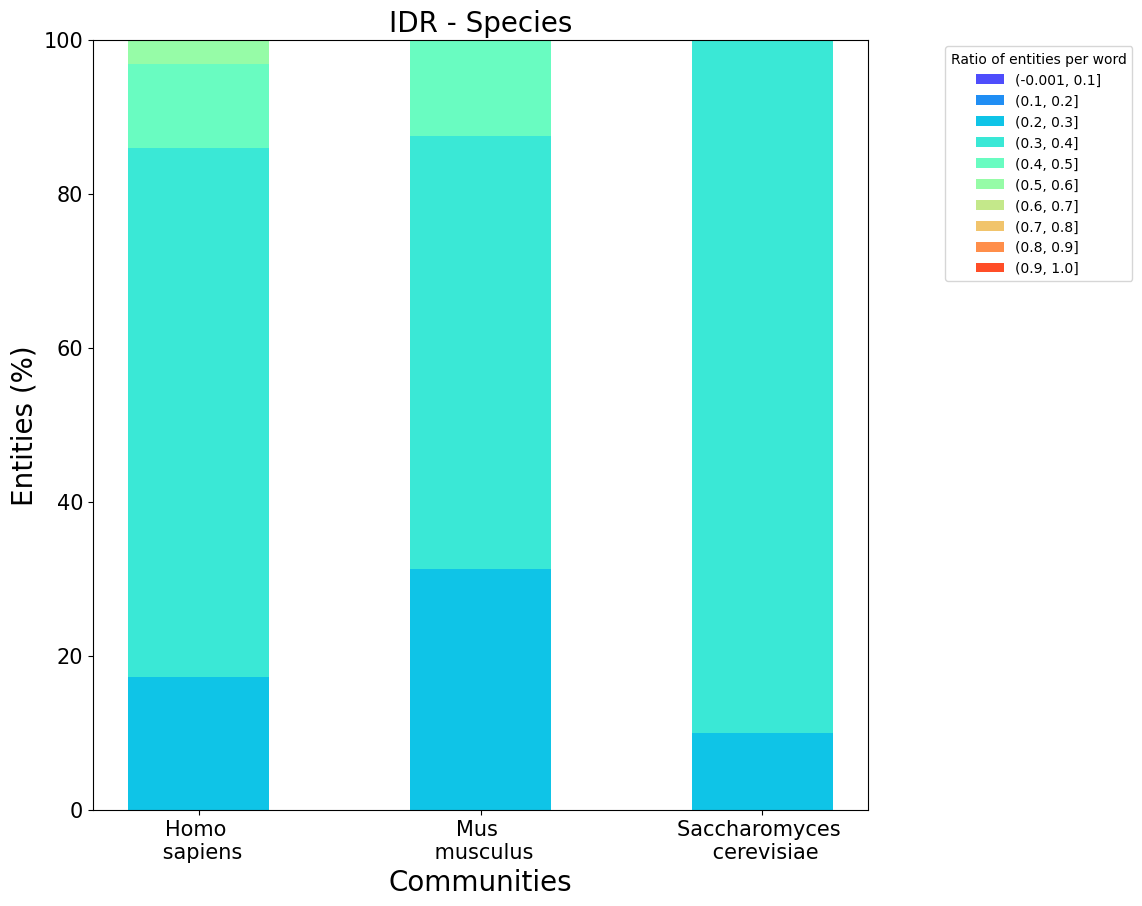

In [122]:
from matplotlib import cm

colors = ['mignightblue','darkslateblue','blue','green', 'yellow','orange', 'red', 'darkblue', 'darkgreen', 'darkorange'] 
palette = cm.rainbow(np.linspace(0.1, 0.9, 10))

plt.subplots(figsize = (10,10))
bar_width = 0.5
index = np.arange(len(communities))

data = np.array(data)
bottom = np.zeros(len(communities))

for i in range(len(values)):
    plt.bar(index, data[:, i], bar_width, bottom = bottom, color = palette[i % len(palette)], label = values[i])
    bottom += data[:,i]


plt.xlabel('Communities', fontsize = 20)
plt.ylabel('Entities (%)', fontsize = 20)

#plt.title('Percentage of the ratio of entities in the abstracts per community')
plt.xticks(index, communities, fontsize = 15)
plt.yticks(fontsize = 15)
plt.title("IDR - Species", fontsize = 20)
plt.legend(title = 'Ratio of entities per word', bbox_to_anchor = (1.35, 1), loc = 'upper right', fontsize = 10)
#plt.tight_layout()
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


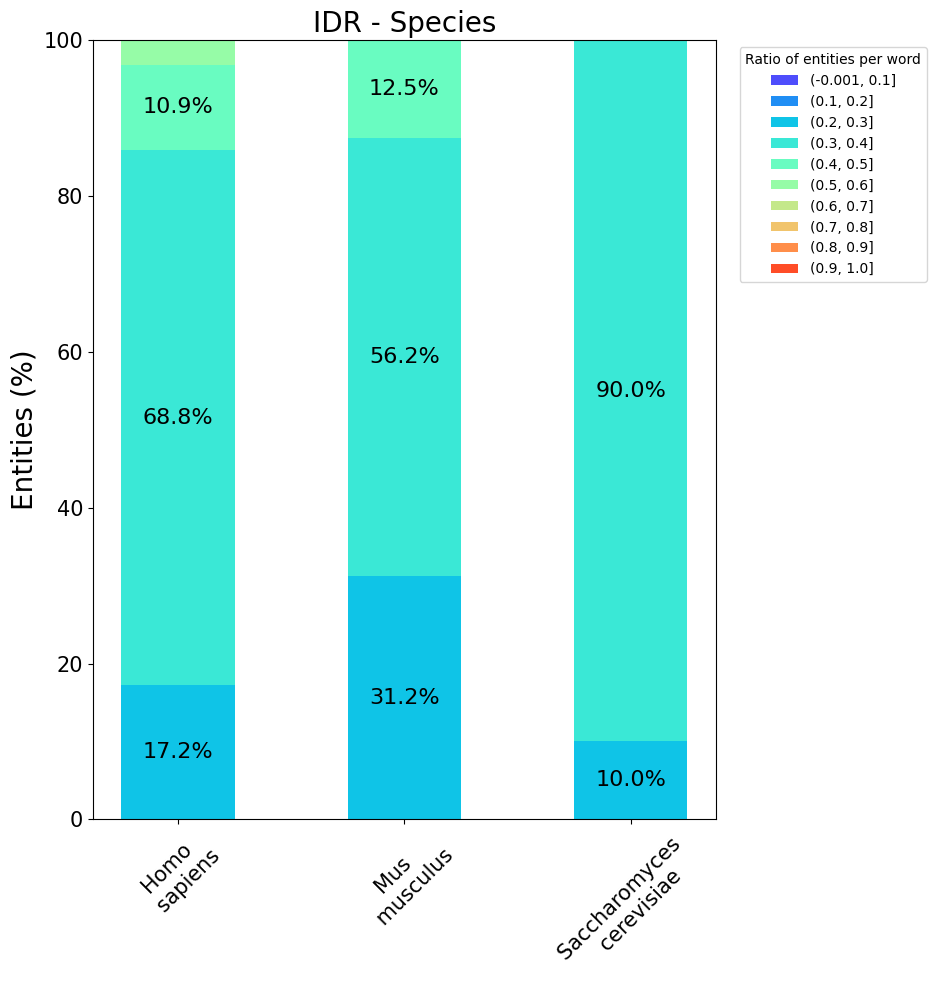

In [123]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

palette = cm.rainbow(np.linspace(0.1, 0.9, 10))

plt.figure(figsize=(10, 10))
bar_width = 0.5
index = np.arange(len(communities))

data = np.array(data)
bottom = np.zeros(len(communities))
threshold = 5

for i in range(len(values)):
    bars = plt.bar(
        index,
        data[:, i],
        bar_width,
        bottom=bottom,
        color=palette[i % len(palette)],
        label=values[i]
    )

    # Add percentage labels centered in each segment
    for j, b in enumerate(bars):
        h = b.get_height()
        if h <= threshold:
            continue

        # Only label segments large enough to read (tweak threshold as you like)
        if h < 2:   # "2" means 2 percentage points
            continue

        x = b.get_x() + b.get_width() / 2
        y = bottom[j] + h / 2
        plt.text(
            x, y,
            f"{h:.1f}%",
            ha="center", va="center",
            #rotation = 90,
            fontsize=16,
            #fontweight="bold",
            color="black"
        )

    bottom += data[:, i]

#plt.xlabel("Communities", fontsize=20)
plt.ylabel("Entities (%)", fontsize=20)
plt.xticks(index, communities, fontsize=15, rotation=45)
plt.yticks(fontsize=15)
plt.title("IDR - Species", fontsize = 20)

plt.legend(
    title="Ratio of entities per word",
    bbox_to_anchor=(1.35, 1),
    loc="upper right",
    fontsize=10
)

plt.tight_layout()

plt.savefig("IDR_info_density_long_entities_20260430.png", dpi=300, bbox_inches="tight")
plt.savefig("IDR_info_density_long_entities_20260430.eps", dpi=300, bbox_inches="tight", format="eps")
plt.savefig("IDR_info_density_long_entities_20260430.pdf", dpi=300, bbox_inches="tight")

plt.show()

#### Stats

In [139]:
g_homo = df_homo['ratio_entities_per_word'].to_list()
g_mus = df_mus['ratio_entities_per_word'].to_list()
g_cerevisiae = df_cerevisiae['ratio_entities_per_word'].to_list()

In [140]:
g_homo

[0.31868131868131866,
 0.38235294117647056,
 0.3333333333333333,
 0.4,
 0.34951456310679613,
 0.3709677419354839,
 0.39805825242718446,
 0.3333333333333333,
 0.33043478260869563,
 0.3258426966292135,
 0.39325842696629215,
 0.29,
 0.3728813559322034,
 0.3113207547169811,
 0.3,
 0.4,
 0.36607142857142855,
 0.45454545454545453,
 0.5,
 0.5454545454545454,
 0.4175824175824176,
 0.4166666666666667,
 0.3409090909090909,
 0.3625,
 0.3382352941176471,
 0.2727272727272727,
 0.359375,
 0.29365079365079366,
 0.4107142857142857,
 0.34375,
 0.34615384615384615,
 0.336734693877551,
 0.3170731707317073,
 0.3113207547169811,
 0.3488372093023256,
 0.27358490566037735,
 0.2826086956521739,
 0.3157894736842105,
 0.34814814814814815,
 0.4175824175824176,
 0.2909090909090909,
 0.2987012987012987,
 0.3069306930693069,
 0.37142857142857144,
 0.3263157894736842,
 0.30337078651685395,
 0.38961038961038963,
 0.3048780487804878,
 0.35802469135802467,
 0.27586206896551724,
 0.42,
 0.3,
 0.38028169014084506,
 0.533

In [141]:
groups = [g_homo, g_mus, g_cerevisiae]

In [142]:
import numpy as np
from scipy import stats

groups = [g_homo, g_mus, g_cerevisiae]

# Remove NaNs (and also drop inf just in case)
clean = []
for g in groups:
    g = np.asarray(g, dtype=float)
    g = g[np.isfinite(g)]          # removes NaN and +/-inf
    clean.append(g)

# Check sizes after cleaning
print([len(g) for g in clean])

F, p = stats.f_oneway(*clean)

print("F =", F, "p =", p)

[64, 16, 10]
F = 1.4542568177692057 p = 0.2391948950689003


In [144]:

# g1..g5 are your arrays/lists
groups = [g_homo, g_mus, g_cerevisiae]
names  = ["Homo sapiens","Mus musculus","Saccharomyces cerevisiae"]

# Clean NaN/inf and build long-format dataframe
vals_list = []
grp_list  = []

for name, g in zip(names, groups):
    g = np.asarray(g, dtype=float)
    g = g[np.isfinite(g)]  # removes NaN and +/-inf
    vals_list.append(g)
    grp_list.append(np.repeat(name, len(g)))

values = np.concatenate(vals_list)
labels = np.concatenate(grp_list)

df = pd.DataFrame({"value": values, "group": labels})
df.groupby("group").size()


group
Homo sapiens                64
Mus musculus                16
Saccharomyces cerevisiae    10
dtype: int64

In [145]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tuk = pairwise_tukeyhsd(endog=df["value"], groups=df["group"], alpha=0.05)
print(tuk)

            Multiple Comparison of Means - Tukey HSD, FWER=0.05            
   group1             group2          meandiff p-adj   lower  upper  reject
---------------------------------------------------------------------------
Homo sapiens             Mus musculus  -0.0129 0.7237 -0.0529 0.0271  False
Homo sapiens Saccharomyces cerevisiae  -0.0333 0.2392  -0.082 0.0154  False
Mus musculus Saccharomyces cerevisiae  -0.0204 0.6785 -0.0781 0.0374  False
---------------------------------------------------------------------------
